In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from brokenaxes import brokenaxes
os.getcwd()


/Users/emmet/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/emmet/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


'/Users/emmet/Documents/GitHub/Thesis/Chapter5_Coevolution'

        pro_comm  n_prophages  n_baccomm_connections
0      PRO_com_0           14                      1
1      PRO_com_1            1                      1
2     PRO_com_10           44                      1
3    PRO_com_100            6                      1
4    PRO_com_101            6                      1
..           ...          ...                    ...
611   PRO_com_95            1                      1
612   PRO_com_96            1                      1
613   PRO_com_97            1                      1
614   PRO_com_98            1                      1
615   PRO_com_99           65                      1

[616 rows x 3 columns]


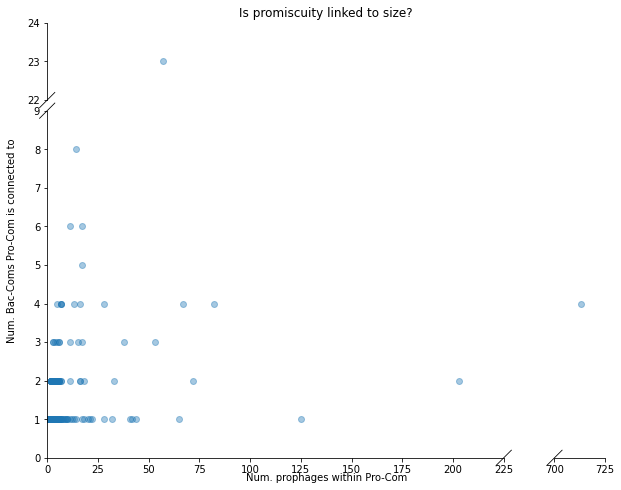

In [2]:
# Q1: Are prophage communties more promiscuous just because they're bigger?
df = pd.read_csv("data/community_questions/q1_procomm_promiscuity.csv")
print(df)

x = df.iloc[:,1]
y = df.iloc[:,2]

fig = plt.figure(figsize=(10, 8))
bax = brokenaxes(xlims=((0,225), (700,725)), ylims=((0,9), (22,24)), hspace=.05)
bax.scatter(x, y, alpha=0.4)
bax.set_title("Is promiscuity linked to size?")
bax.set_xlabel("Num. prophages within Pro-Com")
bax.set_ylabel("Num. Bac-Coms Pro-Com is connected to")


fig.savefig("figures/Q1_promiscuity_vs_size.png", dpi=300, bbox_inches="tight")

        pro_comm  n_prophages   mean_length     sd_length  median_length
0      PRO_com_0           14  35281.000000  13293.849150        29438.0
1      PRO_com_1            1  55798.000000           NaN        55798.0
2     PRO_com_10           44  13028.863636   1180.876805        12584.0
3    PRO_com_100            6  33690.333333    301.814954        33584.0
4    PRO_com_101            6  39789.333333    484.260536        40080.0
..           ...          ...           ...           ...            ...
611   PRO_com_95            1  32300.000000           NaN        32300.0
612   PRO_com_96            1  48042.000000           NaN        48042.0
613   PRO_com_97            1  44866.000000           NaN        44866.0
614   PRO_com_98            1  48198.000000           NaN        48198.0
615   PRO_com_99           65  94202.584615  29543.395029       103526.0

[616 rows x 5 columns]


/Users/emmet/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


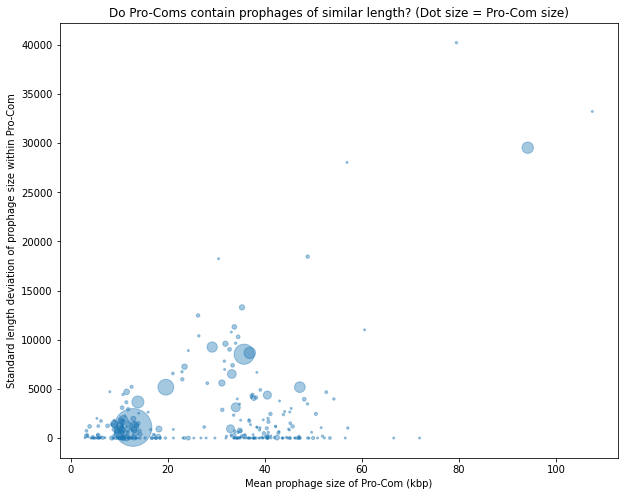

<module 'matplotlib.pyplot' from '/Users/emmet/opt/anaconda3/lib/python3.9/site-packages/matplotlib/pyplot.py'>

In [3]:
# Q2: Do prophage communties all contain prophages of similar sizes?
df = pd.read_csv("data/community_questions/q2_procomm_lengths.csv")
print(df)

x = df.iloc[:,1]
x_log10 = np.log10(x)
y_bp = df.iloc[:,2]
y_kbp = y_bp / 1000
std = (df.iloc[:,3])
r_std = (std)

mean_length = df.iloc[:, 2]
mean_length_kbp = mean_length / 1000
sd_length = df.iloc[:, 3]
log_sd = np.log10(sd_length)
n_prophages = df.iloc[:, 1]
n_prophages_2 = n_prophages * 2

fig = plt.figure(figsize=(10,8))
plt.scatter(mean_length_kbp, sd_length, s=n_prophages_2, alpha=0.4)
plt.title("Do Pro-Coms contain prophages of similar length? (Dot size = Pro-Com size)")
plt.xlabel("Mean prophage size of Pro-Com (kbp)")
plt.ylabel("Standard length deviation of prophage size within Pro-Com")
plt.show()

#plt.scatter(x_log10, y_kbp, s=std, alpha = 0.1)
#plt.show()

#fig = plt.figure(figsize=(20, 18))
#bax = brokenaxes(xlims=((0,225), (700,725)), hspace=.05)
#bax.scatter(x, y_kbp, s=r_std, alpha=0.1)
#bax.set_title("Do Pro Coms contain prophages of similar length?")
#bax.set_xlabel("Num. prophages within Pro-Com")
#bax.set_ylabel("Pro-Com mean prophage length - kbp")

plt

        bac_comm  n_genomes  n_procomm_connections  procomm_per_member
0      BAC_com_0         13                      5            0.384615
1      BAC_com_1         19                      5            0.263158
2     BAC_com_10          1                      2            2.000000
3    BAC_com_100          1                      0            0.000000
4    BAC_com_101          3                      0            0.000000
..           ...        ...                    ...                 ...
209   BAC_com_95          3                      2            0.666667
210   BAC_com_96          1                      0            0.000000
211   BAC_com_97          4                      0            0.000000
212   BAC_com_98          2                      1            0.500000
213   BAC_com_99          1                      0            0.000000

[214 rows x 4 columns]


/Users/emmet/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


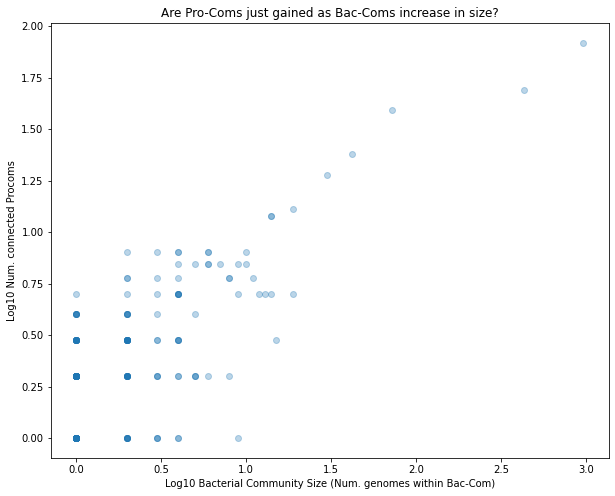

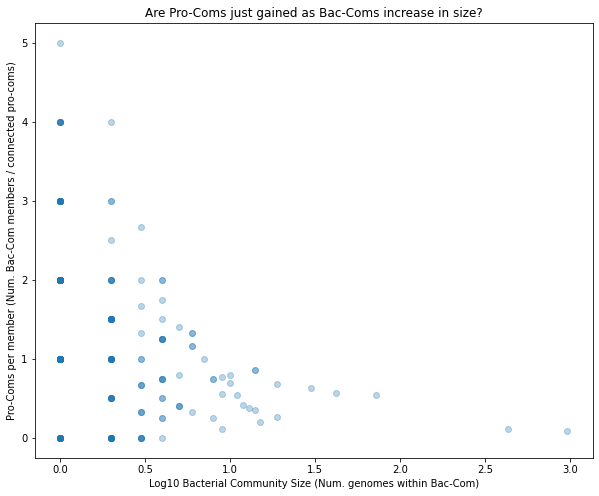

In [4]:
# Q3: Do larger bacterial communties have more infection prophage communities?

df = pd.read_csv("data/community_questions/q3_baccomm_procoms.csv")
print(df)

n_genomes = df.iloc[:, 1]
log_n_genomes = np.log10(n_genomes)
n_procoms = df.iloc[:, 2]
log_n_procoms = np.log10(n_procoms)
procoms_per_member = df.iloc[:, 3]

#fig = plt.figure(figsize=(10, 8))
#bax = brokenaxes(xlims=((0,100), (400,450), (900,1000)), hspace=.05)
#bax.scatter(n_genomes, n_procoms, alpha=0.1)
#bax.set_title("Are Pro-Coms just gained as Bac-Coms increase in size? (All)")
#bax.set_xlabel("Num. genomes within Bac-Com")
#bax.set_ylabel("Num. Pro-Coms connected to the Bac-Com")

fig1 = plt.figure(figsize=(10, 8))
plt.scatter(log_n_genomes, log_n_procoms, alpha=0.3)
plt.title("Are Pro-Coms just gained as Bac-Coms increase in size?")
plt.xlabel("Log10 Bacterial Community Size (Num. genomes within Bac-Com)")
plt.ylabel("Log10 Num. connected Procoms")
plt.show()

fig2 = plt.figure(figsize=(10, 8))
plt.scatter(log_n_genomes, procoms_per_member, alpha=0.3)
plt.title("Are Pro-Coms just gained as Bac-Coms increase in size?")
plt.xlabel("Log10 Bacterial Community Size (Num. genomes within Bac-Com)")
plt.ylabel("Pro-Coms per member (Num. Bac-Com members / connected pro-coms)")
plt.show()

SignificanceResult(statistic=0.23397615499194419, pvalue=0.1900120549983679)


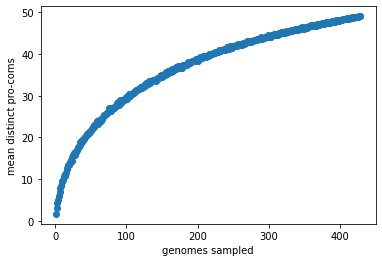

N= 3:  68 communities, rho=+0.24, p=0.050
N= 5:  33 communities, rho=+0.20, p=0.262
N= 8:  22 communities, rho=+0.38, p=0.079
N=10:  16 communities, rho=+0.29, p=0.269
N=12:  13 communities, rho=+0.41, p=0.164
N=15:   8 communities, rho=+0.48, p=0.230
After rarefying all bacterial communities to equal genome sampling depth,
the strong apparent association between community size and prophage-community richness was 
largely abolished (raw log-log slope 0.65, highly significant → rarefied Spearman ρ ≈ 0.2). 
A weak positive residual persisted at every sampling depth (ρ = 0.20–0.48) and was borderline 
significant at the best-powered depth (N = 3, 68 communities, ρ = 0.24, p = 0.05), 
but deeper-depth comparisons were underpowered (≤ 22 communities). We therefore interpret the 
raw size–richness relationship as predominantly a sampling artifact, with at most a weak genuine biological component.


In [5]:
df = pd.read_csv('data/community_questions/q3_genome_procom_links.csv')

# genome -> set of prophage communities it carries
gene_pc = df.dropna(subset=['pro_comm']).groupby('bac_genome')['pro_comm'].apply(set).to_dict()
# all genomes in each community (incl. those carrying nothing)
comm_genomes = df.groupby('bac_comm')['bac_genome'].unique()

rng = np.random.default_rng(42)
def rarefy(genomes, n, reps=200):
    out = []
    for _ in range(reps):
        pick = rng.choice(genomes, n, replace=False)        # subsample n genomes
        seen = set().union(*[gene_pc.get(g, set()) for g in pick])
        out.append(len(seen))                               # distinct pro-coms seen
    return np.mean(out)

N = 5  # subsample every community with >=5 genomes down to 5
res = pd.DataFrame(
    [(c, len(g), rarefy(g, N)) for c, g in comm_genomes.items() if len(g) >= N],
    columns=['bac_comm', 'n_genomes', f'procoms_at_depth{N}'])

from scipy.stats import spearmanr
print(spearmanr(res.n_genomes, res[f'procoms_at_depth{N}']))

gs = comm_genomes['BAC_com_3']
curve = pd.DataFrame([(n, rarefy(gs, n)) for n in range(1, len(gs)+1)],
                     columns=['n_sampled', 'mean_procoms'])
#plot mean_procoms vs n_sampled -> flattening = saturated, still rising = undersampled

plt.scatter(curve['n_sampled'], curve['mean_procoms'])
plt.xlabel('genomes sampled'); plt.ylabel('mean distinct pro-coms'); plt.show()

for N in [3, 5, 8, 10, 12, 15]:
    sub = [(c, len(g), rarefy(g, N)) for c, g in comm_genomes.items() if len(g) >= N]
    r = pd.DataFrame(sub, columns=['c','n','p'])
    rho, pv = spearmanr(r.n, r.p)
    print(f'N={N:2d}: {len(r):3d} communities, rho={rho:+.2f}, p={pv:.3f}')

print("After rarefying all bacterial communities to equal genome sampling depth,\n" + 
      "the strong apparent association between community size and prophage-community richness was \n"
      "largely abolished (raw log-log slope 0.65, highly significant → rarefied Spearman ρ ≈ 0.2). \n" +
      "A weak positive residual persisted at every sampling depth (ρ = 0.20–0.48) and was borderline \n" + 
      "significant at the best-powered depth (N = 3, 68 communities, ρ = 0.24, p = 0.05), \n" + 
      "but deeper-depth comparisons were underpowered (≤ 22 communities). We therefore interpret the \n" + 
      "raw size–richness relationship as predominantly a sampling artifact, with at most a weak genuine biological component.")



#project rarefraction forward = theorhetical limit on the number of prohage communties a bacterial community can hold?

#what is the lcellular limit on propgage communtiy burden 

## Expanding the rarefaction idea (supervisor's two comments)

The cell above rarefies communities **down** to equal depth to strip out the sampling artifact. The two follow-ups take it further:

**1. Project the rarefaction forward → theoretical limit per bacterial community.** Extrapolate each community's genome→pro-com accumulation curve past the genomes we actually have, to its asymptote (Clench model + Chao2 incidence estimator). The asymptote = the max number of distinct prophage communities that community could hold given unlimited sampling.

**2. Cellular limit on prophage burden.** Split genomes into small / medium / large terciles by genome size and rarefy each separately — does a bigger cell host more distinct prophage communities? Key confound handled: prophages themselves add DNA, so we also test burden against the **prophage-free backbone** size.


Median % of prophage-community richness still UNDETECTED (Chao2): 18%
Theoretical max (Chao2) vs community size: rho=+0.57, p=5.3e-04  -> no single fixed ceiling
  bac_comm  n_genomes  S_obs      chao2  pct_undetected
 BAC_com_2        963     83 112.136379       25.982986
 BAC_com_3        429     49  59.537879       17.699453
 BAC_com_5         72     39  63.159722       38.251787
BAC_com_34         42     24  35.811905       32.983179
BAC_com_41         30     19  26.733333       28.927681
BAC_com_37         19     13  24.605263       47.165775


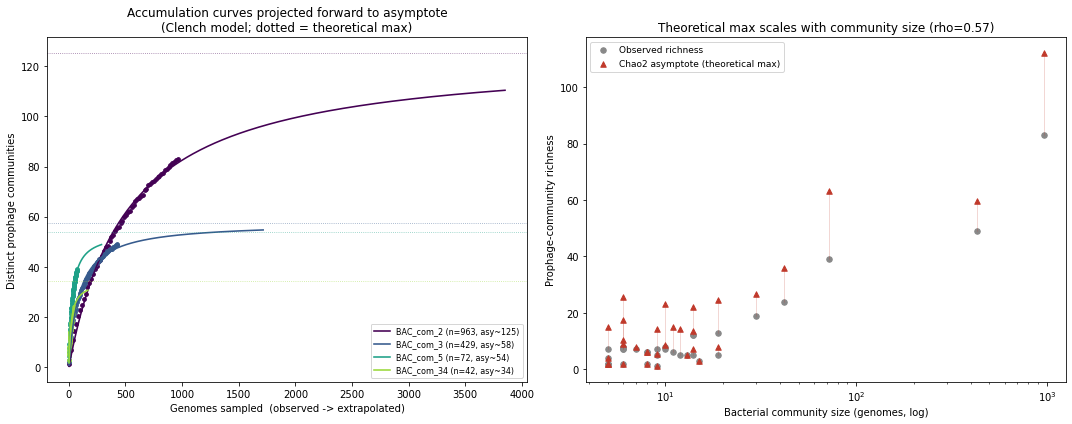

In [6]:
# Q3b: "Project the rarefaction forward = theoretical limit on how many prophage
#       communities a bacterial community can hold?"  (supervisor comment 1)
# Instead of rarefying DOWN to equal depth, EXTRAPOLATE each community's accumulation
# curve past the observed genomes to its asymptote = the theoretical max pro-com richness.
from scipy.stats import spearmanr
from scipy.optimize import curve_fit
from collections import Counter

links = pd.read_csv('data/community_questions/q3_genome_procom_links.csv')
gene_pc = links.dropna(subset=['pro_comm']).groupby('bac_genome')['pro_comm'].apply(set).to_dict()
comm_genomes = links.groupby('bac_comm')['bac_genome'].unique()
rng = np.random.default_rng(42)

def accum_curve(genomes, reps=150, pts=60):                 # mean distinct pro-coms vs n sampled
    genomes = np.asarray(genomes)
    ns = np.unique(np.linspace(1, len(genomes), min(pts, len(genomes))).astype(int))
    return ns, np.array([np.mean([len(set().union(*[gene_pc.get(x, set()) for x in
            rng.choice(genomes, n, replace=False)])) for _ in range(reps)]) for n in ns])

def clench(ns, means):                                      # S(n)=a*n/(1+b*n); asymptote=a/b
    a, b = curve_fit(lambda n, a, b: a*n/(1+b*n), ns, means, p0=[means[-1], .1], maxfev=20000)[0]
    return a, b, (a/b if b > 0 else np.nan)

def chao2(genomes):                                         # incidence-based asymptotic richness
    m = len(genomes); c = Counter()
    for gg in genomes:
        for pc in gene_pc.get(gg, set()): c[pc] += 1
    S = len(c); Q1 = sum(v == 1 for v in c.values()); Q2 = sum(v == 2 for v in c.values())
    est = S + ((m-1)/m)*(Q1*Q1)/(2*Q2) if Q2 > 0 else S + ((m-1)/m)*Q1*(Q1-1)/2
    return S, est

# asymptote per community (>=5 genomes)
rows = []
for c, gs in comm_genomes.items():
    if len(gs) < 5: continue
    S, ch = chao2(gs)
    rows.append((c, len(gs), S, ch))
asy = pd.DataFrame(rows, columns=['bac_comm', 'n_genomes', 'S_obs', 'chao2'])
asy['pct_undetected'] = 100*(asy.chao2 - asy.S_obs)/asy.chao2
print(f"Median % of prophage-community richness still UNDETECTED (Chao2): {asy.pct_undetected.median():.0f}%")
rho, p = spearmanr(asy.n_genomes, asy.chao2)
print(f"Theoretical max (Chao2) vs community size: rho={rho:+.2f}, p={p:.1e}  -> no single fixed ceiling")
print(asy.sort_values('n_genomes', ascending=False).head(6).to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
for c, col in zip(['BAC_com_2','BAC_com_3','BAC_com_5','BAC_com_34'],
                  plt.cm.viridis(np.linspace(0, .85, 4))):
    gs = comm_genomes[c]; ns, means = accum_curve(gs)
    a, b, a_asy = clench(ns, means)
    xext = np.linspace(1, ns.max()*4, 300)
    ax1.scatter(ns, means, s=14, color=col)
    ax1.plot(xext, a*xext/(1+b*xext), color=col, lw=1.6, label=f'{c} (n={len(gs)}, asy~{a_asy:.0f})')
    ax1.axhline(a_asy, color=col, ls=':', lw=.8, alpha=.6)
ax1.set_xlabel('Genomes sampled  (observed -> extrapolated)')
ax1.set_ylabel('Distinct prophage communities')
ax1.set_title('Accumulation curves projected forward to asymptote\n(Clench model; dotted = theoretical max)')
ax1.legend(fontsize=8)

ax2.scatter(asy.n_genomes, asy.S_obs, s=30, color='#888', label='Observed richness')
ax2.scatter(asy.n_genomes, asy.chao2, s=30, marker='^', color='#c0392b', label='Chao2 asymptote (theoretical max)')
for _, r in asy.iterrows():
    ax2.plot([r.n_genomes]*2, [r.S_obs, r.chao2], color='#c0392b', lw=.5, alpha=.4)
ax2.set_xscale('log'); ax2.set_xlabel('Bacterial community size (genomes, log)')
ax2.set_ylabel('Prophage-community richness')
ax2.set_title(f'Theoretical max scales with community size (rho={rho:.2f})')
ax2.legend(fontsize=9)
plt.tight_layout(); plt.savefig('figures/Rarefaction_projected_forward.png', dpi=150, bbox_inches='tight'); plt.show()

# TAKEAWAY: even the best-sampled communities are only ~75-82% saturated (median ~18% of pro-com
# richness still unseen), so none has hit a hard ceiling. The extrapolated asymptote itself keeps
# rising with community size (rho ~0.57) -> larger bacterial communities can hold proportionally
# more distinct prophage communities; there is no single universal upper limit in this dataset.


/var/folders/hs/05pc8tk14_b99kxwhdwqq46r0000gq/T/ipykernel_43549/3780667331.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  size_stats = g.groupby('size_class')['size'].agg(n='size', mean='mean', median='median', sd='std')
/var/folders/hs/05pc8tk14_b99kxwhdwqq46r0000gq/T/ipykernel_43549/3780667331.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print("Kruskal-Wallis burden across size classes:", kruskal(*[x.burden.values for _, x in g.groupby('size_class')]))
/var/folders/hs/05pc8tk14_b99kxwhdwqq46r0000gq/T/ipykernel_43549/3780667331.py:44: FutureWarning: The default of observed=False is deprecated 

Per-tercile genome size (Mb):
              n  mean_Mb  median_Mb  sd_Mb
size_class                                
small       707    2.030      2.044  0.066
medium      706    2.115      2.114  0.028
large       706    2.296      2.264  0.106
per-genome burden vs TOTAL size:    rho = +0.512
per-genome burden vs BACKBONE size: rho = +0.278   (prophage bp removed)
prophage DNA = 1.7% of the average genome; max in one genome = 254,611 bp
Kruskal-Wallis burden across size classes: KruskalResult(statistic=564.1761976781216, pvalue=3.09524665988081e-123)
              n  mean_burden  max_burden
size_class                              
small       707     0.881188           3
medium      706     1.413598           5
large       706     2.216714           6


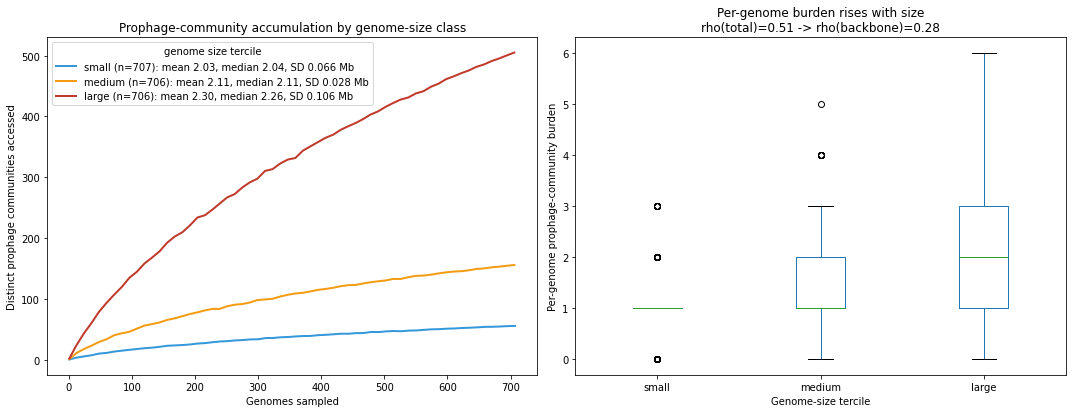

In [7]:
# Q3c: "What is the cellular limit on prophage-community burden?"  (supervisor comment 2)
# The requested small / medium / large genome rarefaction.
# Idea: does the size of the bacterial cell cap how many distinct prophage communities it hosts?
import re
from scipy.stats import spearmanr, kruskal

links = pd.read_csv('data/community_questions/q3_genome_procom_links.csv')
bv    = pd.read_csv('data/SupplementaryTable1-BVBRC_29Nov23.csv', low_memory=False)
promap = pd.read_csv('data/genome_community_mapping_44_PRO.csv')   # every provirus, coords in its ID

gene_pc = links.dropna(subset=['pro_comm']).groupby('bac_genome')['pro_comm'].apply(set).to_dict()

# per-genome table: size, burden (# distinct pro-coms carried)
g = links[['bac_genome']].drop_duplicates().copy()
g['gid_raw'] = g['bac_genome'].str.replace('.fna', '', regex=False)
g['size']    = ('Ssuis_' + g['gid_raw']).map(bv.set_index('Genome ID')['Size'].to_dict())
g['burden']  = g['bac_genome'].map(lambda x: len(gene_pc.get(x, set())))

# --- CONFOUND: prophages inflate genome size, so subtract prophage bp -> "backbone" size ---
# provirus IDs encode coords, e.g. 1004951.3_CP002651_provirus-1291910-1341951.fna
pat = re.compile(r'^(\d+\.\d+)_.*provirus-(\d+)-(\d+)\.fna$')
def _plen(pid):
    m = pat.match(pid)
    return pd.Series([m.group(1), abs(int(m.group(3)) - int(m.group(2)))]) if m else pd.Series([None, None])
promap[['gr', 'pl']] = promap['Genome_ID'].apply(_plen)
g['prophage_bp'] = g['gid_raw'].map(promap.groupby('gr')['pl'].sum()).fillna(0)
g['backbone']    = g['size'] - g['prophage_bp']
g = g.dropna(subset=['size'])
g['size_class'] = pd.qcut(g['size'], 3, labels=['small', 'medium', 'large'])

# per-tercile genome-size stats (mean/median/SD) -- reported in the legend + thesis caption
size_stats = g.groupby('size_class')['size'].agg(n='size', mean='mean', median='median', sd='std')
print('Per-tercile genome size (Mb):')
print((size_stats.assign(mean_Mb=size_stats['mean']/1e6, median_Mb=size_stats['median']/1e6,
        sd_Mb=size_stats['sd']/1e6))[['n','mean_Mb','median_Mb','sd_Mb']].round(3).to_string())

rho_tot = spearmanr(g['size'], g['burden'])[0]
rho_bb  = spearmanr(g['backbone'], g['burden'])[0]
print(f"per-genome burden vs TOTAL size:    rho = {rho_tot:+.3f}")
print(f"per-genome burden vs BACKBONE size: rho = {rho_bb:+.3f}   (prophage bp removed)")
print(f"prophage DNA = {100*g['prophage_bp'].mean()/g['size'].mean():.1f}% of the average genome; "
      f"max in one genome = {g['prophage_bp'].max():,.0f} bp")
print("Kruskal-Wallis burden across size classes:", kruskal(*[x.burden.values for _, x in g.groupby('size_class')]))
print(g.groupby('size_class').agg(n=('bac_genome','size'),
      mean_burden=('burden','mean'), max_burden=('burden','max')))

# --- accumulation curve per size class (distinct pro-coms accessed vs genomes sampled) ---
rng = np.random.default_rng(42)
def accum(genomes, reps=80, pts=60):
    genomes = np.asarray(genomes)
    ns = np.unique(np.linspace(1, len(genomes), min(pts, len(genomes))).astype(int))
    return ns, np.array([np.mean([len(set().union(*[gene_pc.get(x, set()) for x in
            rng.choice(genomes, n, replace=False)])) for _ in range(reps)]) for n in ns])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
cmap = {'small': '#3498db', 'medium': '#f39c12', 'large': '#c0392b'}
for cls in ['small', 'medium', 'large']:
    ns, means = accum(g[g.size_class == cls]['bac_genome'].values)
    m=size_stats.loc[cls,'mean']/1e6; md=size_stats.loc[cls,'median']/1e6; sd=size_stats.loc[cls,'sd']/1e6
    ax1.plot(ns, means, color=cmap[cls], lw=2,
             label=f'{cls} (n={int(size_stats.loc[cls,"n"])}): mean {m:.2f}, median {md:.2f}, SD {sd:.3f} Mb')
ax1.set_xlabel('Genomes sampled'); ax1.set_ylabel('Distinct prophage communities accessed')
ax1.set_title('Prophage-community accumulation by genome-size class')
ax1.legend(title='genome size tercile')
# NB: the large-genome curve does NOT saturate over the observed range -> repertoire not yet exhausted

g.boxplot(column='burden', by='size_class', ax=ax2, grid=False)
ax2.set_xlabel('Genome-size tercile'); ax2.set_ylabel('Per-genome prophage-community burden')
ax2.set_title(f'Per-genome burden rises with size\nrho(total)={rho_tot:.2f} -> rho(backbone)={rho_bb:.2f}')
plt.suptitle(''); plt.tight_layout()
plt.savefig('figures/Rarefaction_by_genome_size.png', dpi=150, bbox_inches='tight'); plt.show()

# TAKEAWAY: bigger genomes carry more prophage communities (rho +0.51). About half of that is
# mechanical (prophages themselves add DNA); a genuine residual survives on prophage-free backbone
# (rho +0.28). Per-cell ceiling is ~6 distinct pro-coms; large genomes sit closest to it, and as a
# pool they access an order of magnitude more distinct pro-coms than small genomes at equal depth.


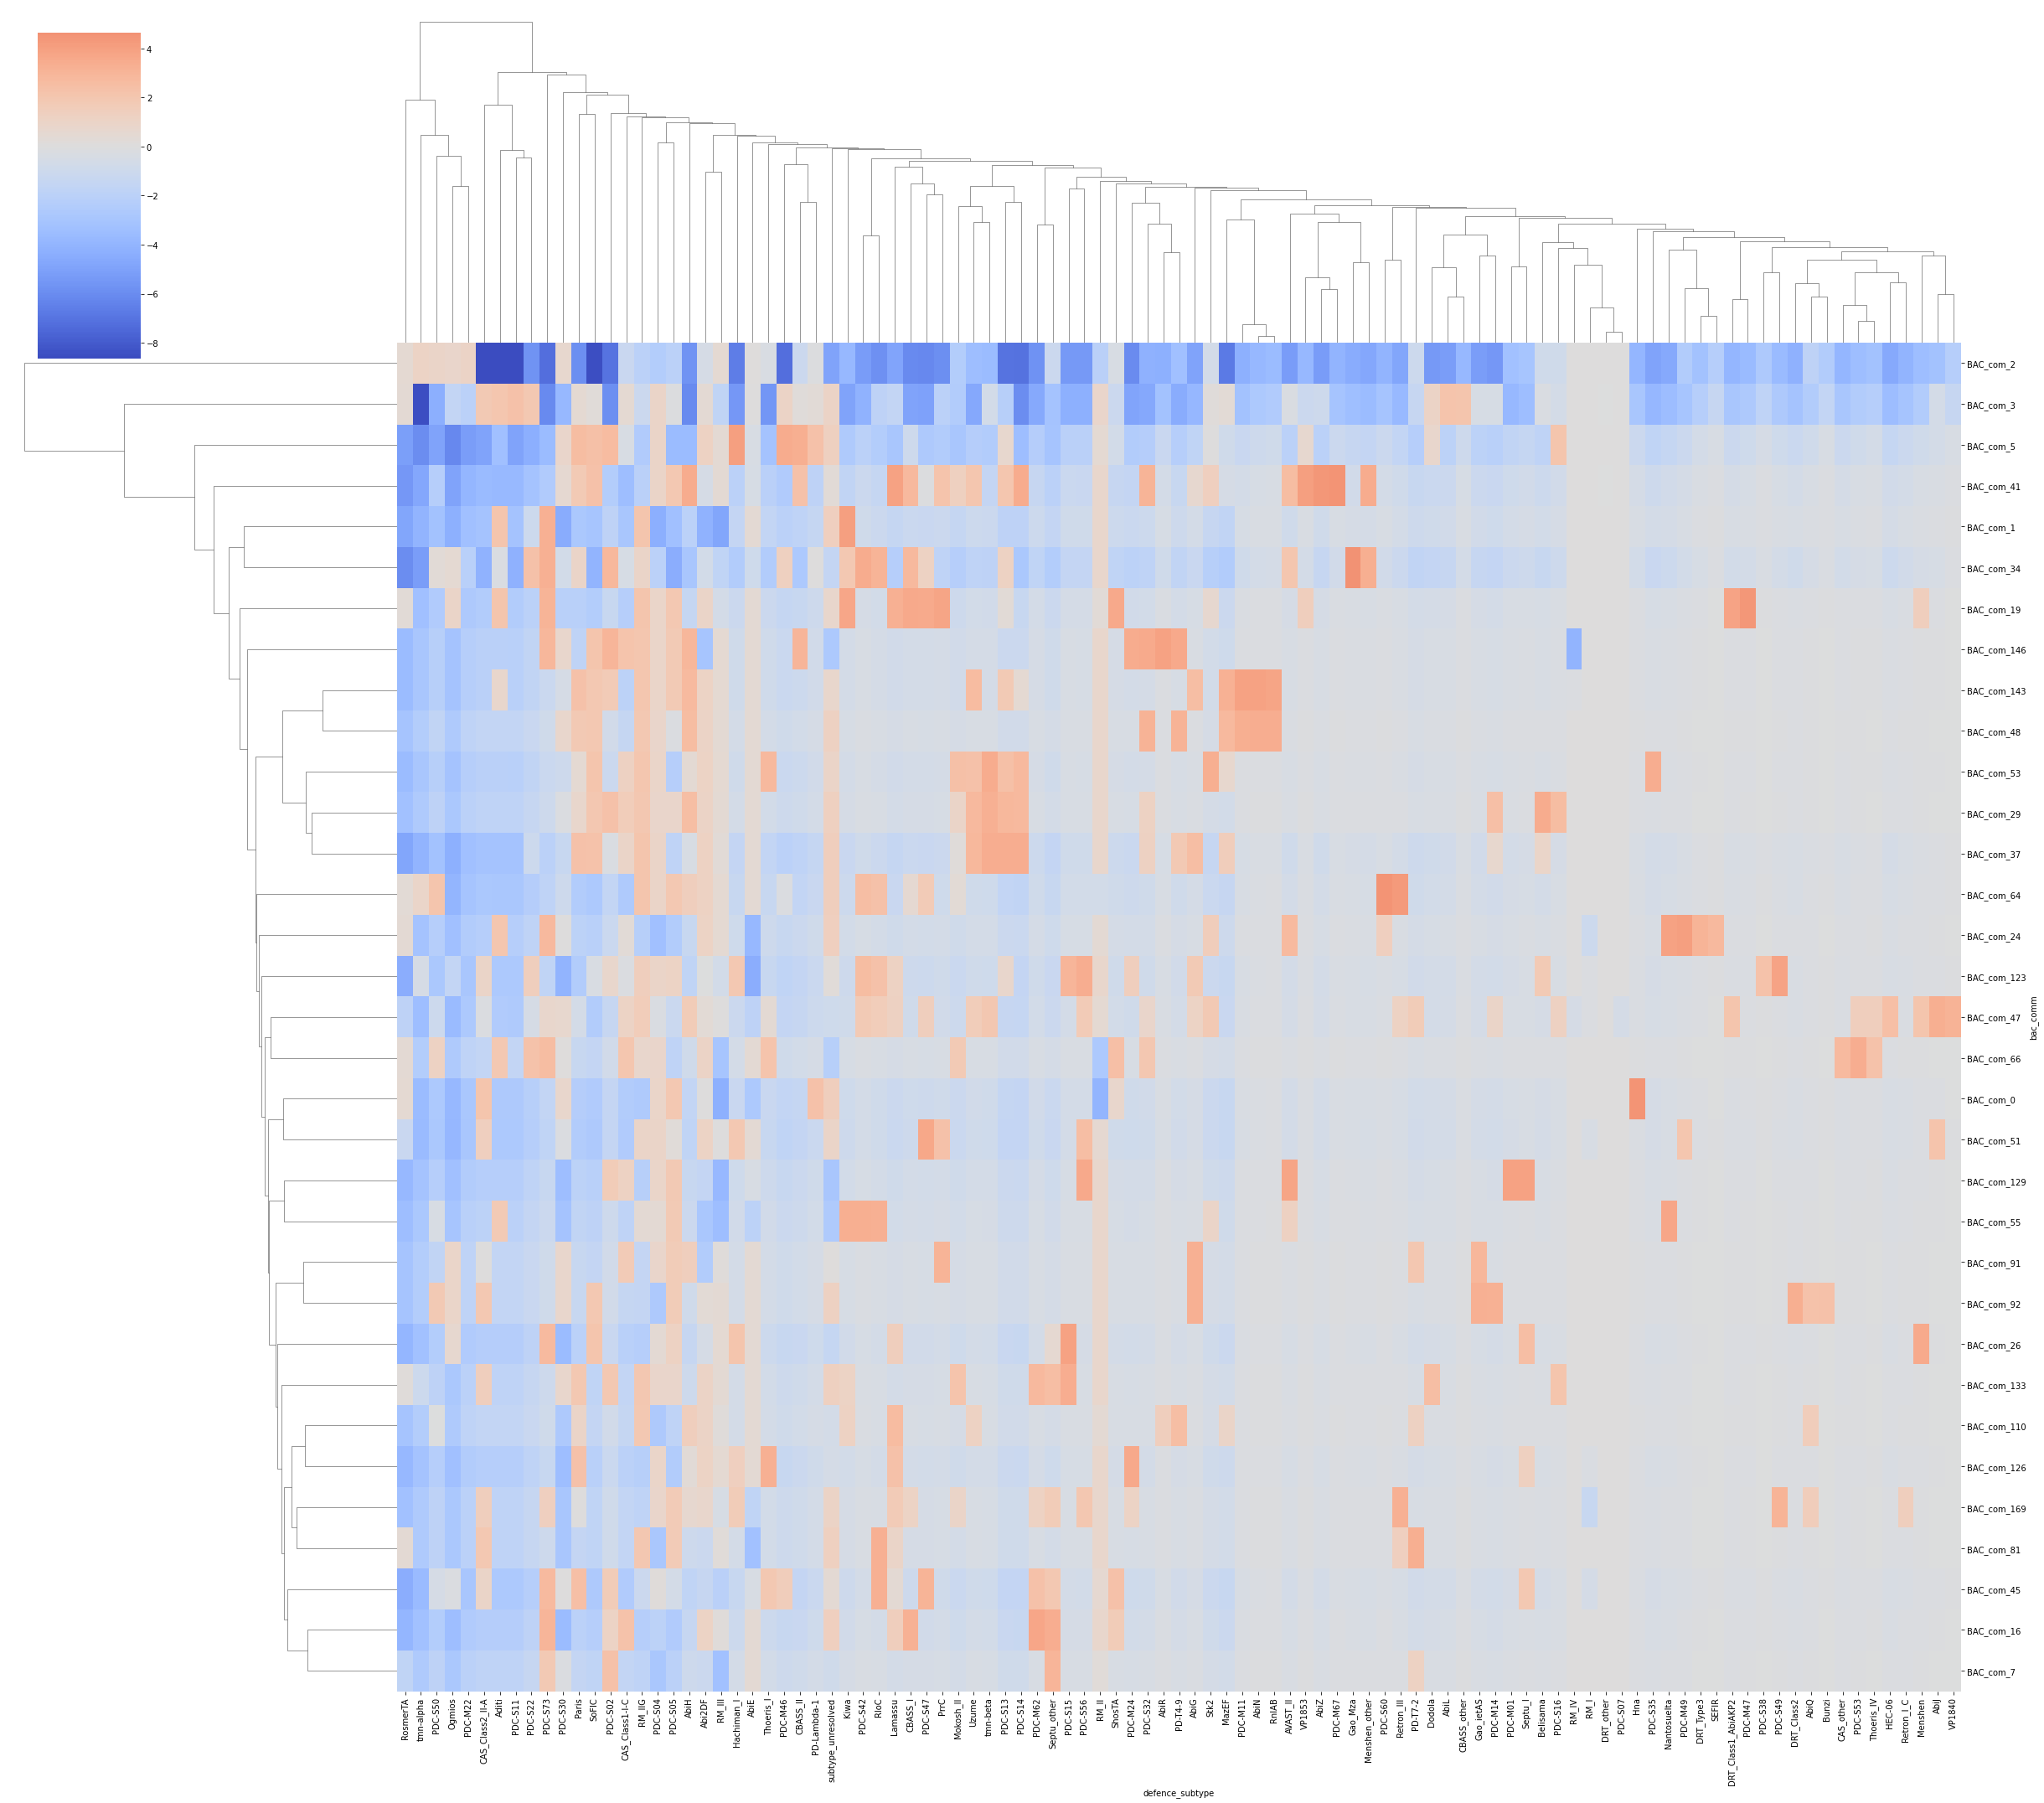

In [8]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
q4 = pd.read_csv('data/community_questions/q4_baccomm_defence_enrichment.csv')
q4 = q4[q4.n_in_comm >= 5]                                   # drop tiny communities
sig_subs = q4.loc[q4.significant, 'defence_subtype'].unique()  # subtypes with real signal
M = (q4[q4.defence_subtype.isin(sig_subs)]
       .pivot(index='bac_comm', columns='defence_subtype', values='log2OE')
       .fillna(0))
sns.clustermap(M, cmap='coolwarm', center=0, figsize=(34, 30))
plt.show()

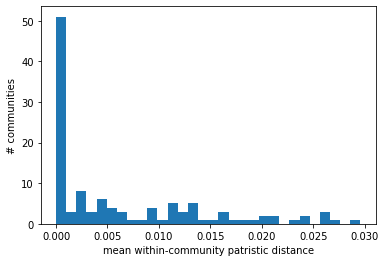

In [9]:
import pandas as pd, matplotlib.pyplot as plt
from scipy.stats import spearmanr
q5 = pd.read_csv('data/community_questions/q5_community_phylo_distance.csv').dropna(subset=['mean_pair_dist'])

# 1. the distribution: are some communities tight, others diverse?
plt.hist(q5.mean_pair_dist, bins=30)
plt.xlabel('mean within-community patristic distance'); plt.ylabel('# communities'); plt.show()

SignificanceResult(statistic=0.1380448025324322, pvalue=0.13603127870465734)


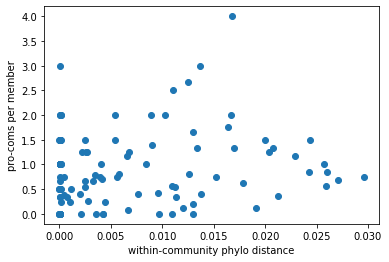

In [10]:
q3 = pd.read_csv('data/community_questions/q3_baccomm_procoms.csv')
m = q5.merge(q3, on='bac_comm')
print(spearmanr(m.mean_pair_dist, m.procomm_per_member))
plt.scatter(m.mean_pair_dist, m.procomm_per_member)
plt.xlabel('within-community phylo distance'); plt.ylabel('pro-coms per member'); plt.show()

per-genome prophage count vs mean size: Spearman rho=0.370, p=3.14e-61, n=1849 genomes
       size  mean  median
n_pro                    
1       979  19.0    13.1
2       535  29.7    26.6
3       216  25.9    24.1
4        83  22.0    22.1
5        31  21.6    21.4
6         4  25.7    26.7
8         1  25.9    25.9


/var/folders/hs/05pc8tk14_b99kxwhdwqq46r0000gq/T/ipykernel_43549/913621589.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[f'{c}\n(n={len(d)})' for c, d in zip(counts, data)],


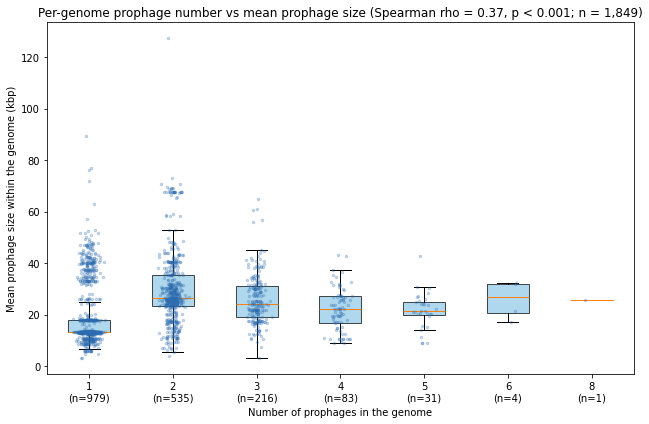

In [11]:
# Results 5.2.1 -- prophage abundance: per-genome prophage COUNT vs mean prophage SIZE.
# Supplementary figure behind the "Spearman rho = 0.37" sentence: do genomes with
# more prophages carry larger ones? Data = genome_community_mapping_44_PRO.csv
# (every provirus; start/end coords are embedded in its ID -> length).
import re
from scipy.stats import spearmanr

pro = pd.read_csv('data/genome_community_mapping_44_PRO.csv')
pat = re.compile(r'^(\d+\.\d+)_.*provirus-(\d+)-(\d+)\.fna$')
def _parse(pid):
    m = pat.match(pid)
    return pd.Series([m.group(1), abs(int(m.group(3)) - int(m.group(2)))]) if m else pd.Series([None, None])
pro[['gid', 'plen']] = pro['Genome_ID'].apply(_parse)

# per genome: number of prophages + mean prophage size (kbp)
g = pro.groupby('gid').agg(n_pro=('plen', 'size'), mean_kbp=('plen', lambda s: s.mean() / 1000))
rho, p = spearmanr(g.n_pro, g.mean_kbp)
print(f'per-genome prophage count vs mean size: Spearman rho={rho:.3f}, p={p:.2e}, n={len(g)} genomes')
print(g.groupby('n_pro')['mean_kbp'].agg(['size', 'mean', 'median']).round(1))

fig, ax = plt.subplots(figsize=(9, 6))
counts = sorted(g.n_pro.unique())
data = [g[g.n_pro == c]['mean_kbp'].values for c in counts]
bp = ax.boxplot(data, labels=[f'{c}\n(n={len(d)})' for c, d in zip(counts, data)],
                showfliers=False, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('#8ec6e6'); patch.set_alpha(0.7)
for i, d in enumerate(data, 1):                       # jittered points over the boxes
    ax.scatter(np.random.normal(i, 0.06, len(d)), d, s=6, color='#2d6cb0', alpha=0.25, zorder=3)
ax.set_xlabel('Number of prophages in the genome')
ax.set_ylabel('Mean prophage size within the genome (kbp)')
ax.set_title(f'Per-genome prophage number vs mean prophage size '
             f'(Spearman rho = {rho:.2f}, p < 0.001; n = {len(g):,})')
plt.tight_layout()
plt.savefig('Figures/prophage_count_vs_size.png', dpi=200, bbox_inches='tight')
plt.show()
# NB: thesis uses this as Supplementary fig:supp_count_size -- copy the PNG to
#     0_Main_Thesis/Chp4 Coevolution/figures/  (already placed there once).


In [12]:
# Results 5.2.2 -- how promiscuous are prophage communities?
# For each of the 616 prophage communities: how many DISTINCT bacterial communities
# does it connect to (i.e. infect)?  1 = host-specific motif; >=2 = promiscuous motif.
prom = pd.read_csv('data/community_questions/q1_procomm_promiscuity.csv')
nb = prom['n_baccomm_connections']
print(f'total prophage communities:       {len(prom)}')
print(f'host-specific (exactly 1 bac-com): {(nb == 1).sum()} ({100*(nb == 1).mean():.0f}%)')
print(f'promiscuous (>= 2 bac-coms):       {(nb >= 2).sum()} ({100*(nb >= 2).mean():.0f}%)')
print(f'   ... of which >= 5 bac-coms: {(nb >= 5).sum()};  >= 10 bac-coms: {(nb >= 10).sum()}')
print(f'most promiscuous pro-com spans {nb.max()} bacterial communities')
print('\nfull distribution (n bac-coms connected -> n pro-coms):')
print(nb.value_counts().sort_index())


total prophage communities:       616
host-specific (exactly 1 bac-com): 545 (88%)
promiscuous (>= 2 bac-coms):       71 (12%)
   ... of which >= 5 bac-coms: 5;  >= 10 bac-coms: 1
most promiscuous pro-com spans 23 bacterial communities

full distribution (n bac-coms connected -> n pro-coms):
n_baccomm_connections
1     545
2      45
3      11
4      10
5       1
6       2
8       1
23      1
Name: count, dtype: int64


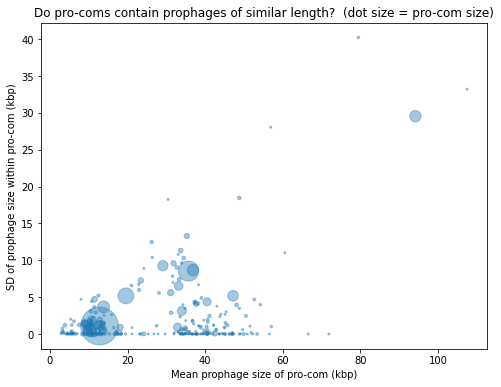

/Users/emmet/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


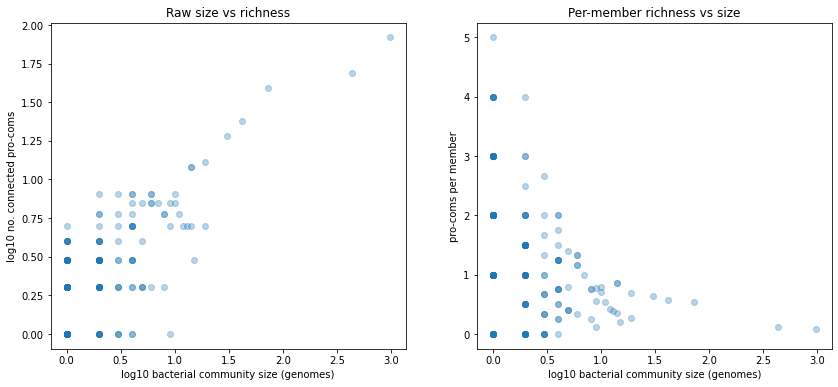

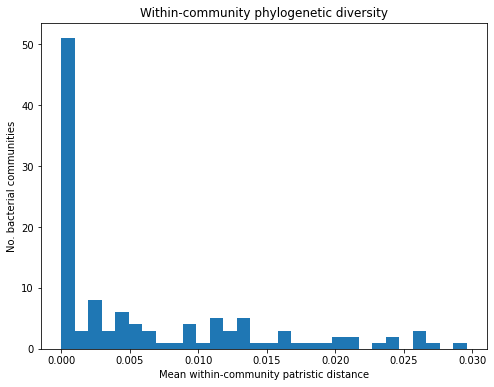

Q6 Spearman: rho=0.138, p=0.136, n=118


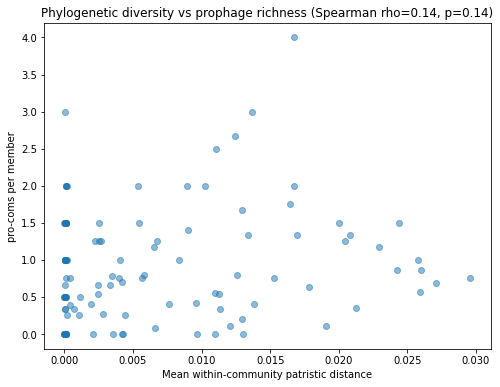

In [13]:
# Save the Q2/Q3/Q5/Q6 exploratory figures for the thesis SUPPLEMENTARY (Chapter 4).
# Reproduces the plots from the Q2/Q3/Q5/Q6 cells above and writes them to Figures/.
# (Copy the PNGs to 0_Main_Thesis/Chp4 Coevolution/figures/ for the thesis.)
from scipy.stats import spearmanr

# Q2 -- prophage-size homogeneity within pro-coms
q2 = pd.read_csv("data/community_questions/q2_procomm_lengths.csv")
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(q2.mean_length/1000, q2.sd_length/1000, s=q2.n_prophages*2, alpha=0.4)
ax.set_xlabel("Mean prophage size of pro-com (kbp)"); ax.set_ylabel("SD of prophage size within pro-com (kbp)")
ax.set_title("Do pro-coms contain prophages of similar length?  (dot size = pro-com size)")
fig.savefig("Figures/q2_procom_length_homogeneity.png", dpi=200, bbox_inches="tight"); plt.show()

# Q3 -- raw bacterial community size vs prophage-community richness
q3 = pd.read_csv("data/community_questions/q3_baccomm_procoms.csv")
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 6))
a1.scatter(np.log10(q3.n_genomes), np.log10(q3.n_procomm_connections), alpha=0.3)
a1.set_xlabel("log10 bacterial community size (genomes)"); a1.set_ylabel("log10 no. connected pro-coms"); a1.set_title("Raw size vs richness")
a2.scatter(np.log10(q3.n_genomes), q3.procomm_per_member, alpha=0.3)
a2.set_xlabel("log10 bacterial community size (genomes)"); a2.set_ylabel("pro-coms per member"); a2.set_title("Per-member richness vs size")
fig.savefig("Figures/q3_baccom_size_vs_procoms.png", dpi=200, bbox_inches="tight"); plt.show()

# Q5 -- within-community phylogenetic diversity
q5 = pd.read_csv("data/community_questions/q5_community_phylo_distance.csv").dropna(subset=['mean_pair_dist'])
fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(q5.mean_pair_dist, bins=30)
ax.set_xlabel("Mean within-community patristic distance"); ax.set_ylabel("No. bacterial communities")
ax.set_title("Within-community phylogenetic diversity")
fig.savefig("Figures/q5_within_community_phylo_distance.png", dpi=200, bbox_inches="tight"); plt.show()

# Q6 -- phylogenetic diversity vs prophage richness (no significant link)
m = q5.merge(q3, on='bac_comm')
rho, p = spearmanr(m.mean_pair_dist, m.procomm_per_member)
print(f"Q6 Spearman: rho={rho:.3f}, p={p:.3f}, n={len(m)}")
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(m.mean_pair_dist, m.procomm_per_member, alpha=0.5)
ax.set_xlabel("Mean within-community patristic distance"); ax.set_ylabel("pro-coms per member")
ax.set_title(f"Phylogenetic diversity vs prophage richness (Spearman rho={rho:.2f}, p={p:.2f})")
fig.savefig("Figures/q6_phylo_distance_vs_procoms.png", dpi=200, bbox_inches="tight"); plt.show()


(A) prophage-free vs prophage-carrying  (n = 270 vs 1849)
  Contigs     median         56 vs         56  MWU p=0.993  |  vs n_prophages: rho=+0.038, p=0.0814
  Contig N50  median    130,823 vs    122,806  MWU p=0.305  |  vs n_prophages: rho=-0.055, p=0.0107

(B) assembly quality across genome-size terciles
              Size  Contigs  Contig N50  n_prophages
tercile                                             
small    2043655.0     39.0    170279.0          1.0
medium   2113890.0     56.0    103334.0          1.0
large    2264106.0     86.0     74950.0          2.0
  Contigs     KW p=6.7e-58  |  vs assembly size: rho=+0.382, p=1.43e-74
  Contig N50  KW p=7.56e-53  |  vs assembly size: rho=-0.353, p=4.93e-63


/var/folders/hs/05pc8tk14_b99kxwhdwqq46r0000gq/T/ipykernel_43549/2685907552.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(gm.groupby('tercile')[['Size', 'Contigs', 'Contig N50', 'n_prophages']].median().round(0))
/var/folders/hs/05pc8tk14_b99kxwhdwqq46r0000gq/T/ipykernel_43549/2685907552.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, showfliers=False, patch_artist=True)
/var/folders/hs/05pc8tk14_b99kxwhdwqq46r0000gq/T/ipykernel_43549/2685907552.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  

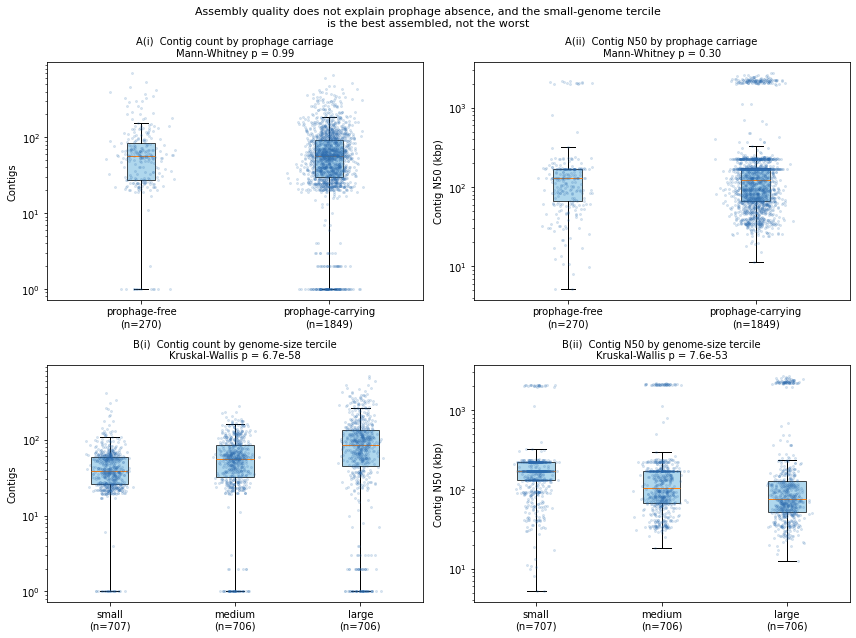

In [14]:
# Results 5.2 -- assembly-quality confounder check (supervisor comments 126 / 199 / 315).
# Two questions, one figure:
#   (A) is prophage ABSENCE just poor assembly?   0 prophages vs >=1, contigs and N50
#   (B) are the genome-size TERCILES just an assembly-quality gradient?
# Data = data/confounders/genome_master_table.csv (BV-BRC assembly metrics + prophage counts).
from scipy.stats import mannwhitneyu, kruskal, spearmanr

gm = pd.read_csv('data/confounders/genome_master_table.csv')
gm['carrier'] = np.where(gm.n_prophages > 0, 'prophage-carrying', 'prophage-free')
gm['tercile'] = pd.qcut(gm.Size, 3, labels=['small', 'medium', 'large'])

# --- (A) presence/absence vs assembly quality -------------------------------
print('(A) prophage-free vs prophage-carrying  (n = %d vs %d)'
      % ((gm.n_prophages == 0).sum(), (gm.n_prophages > 0).sum()))
for col in ['Contigs', 'Contig N50']:
    free = gm.loc[gm.n_prophages == 0, col]
    carr = gm.loc[gm.n_prophages > 0, col]
    u, p = mannwhitneyu(free, carr)
    rho, rp = spearmanr(gm[col], gm.n_prophages)
    print(f'  {col:<11} median {free.median():>10,.0f} vs {carr.median():>10,.0f}  '
          f'MWU p={p:.3g}  |  vs n_prophages: rho={rho:+.3f}, p={rp:.3g}')

# --- (B) size terciles vs assembly quality ----------------------------------
print('\n(B) assembly quality across genome-size terciles')
print(gm.groupby('tercile')[['Size', 'Contigs', 'Contig N50', 'n_prophages']].median().round(0))
for col in ['Contigs', 'Contig N50']:
    groups = [gm.loc[gm.tercile == t, col] for t in ['small', 'medium', 'large']]
    h, p = kruskal(*groups)
    rho, rp = spearmanr(gm.Size, gm[col])
    print(f'  {col:<11} KW p={p:.3g}  |  vs assembly size: rho={rho:+.3f}, p={rp:.3g}')

# --- figure ------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 9))


def _box(ax, data, labels, ylab, title, log=False):
    bp = ax.boxplot(data, labels=labels, showfliers=False, patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('#8ec6e6'); patch.set_alpha(0.7)
    for i, d in enumerate(data, 1):
        ax.scatter(np.random.normal(i, 0.06, len(d)), d, s=4, color='#2d6cb0', alpha=0.15, zorder=3)
    if log:
        ax.set_yscale('log')
    ax.set_ylabel(ylab); ax.set_title(title, fontsize=10)


carr_groups = [gm.loc[gm.carrier == c] for c in ['prophage-free', 'prophage-carrying']]
carr_labels = [f'prophage-free\n(n={len(carr_groups[0])})',
               f'prophage-carrying\n(n={len(carr_groups[1])})']
terc_groups = [gm.loc[gm.tercile == t] for t in ['small', 'medium', 'large']]
terc_labels = [f'{t}\n(n={len(g)})' for t, g in zip(['small', 'medium', 'large'], terc_groups)]

_box(axes[0, 0], [g.Contigs.values for g in carr_groups], carr_labels, 'Contigs',
     'A(i)  Contig count by prophage carriage\n'
     f'Mann-Whitney p = {mannwhitneyu(carr_groups[0].Contigs, carr_groups[1].Contigs)[1]:.2f}', log=True)
_box(axes[0, 1], [g['Contig N50'].values / 1000 for g in carr_groups], carr_labels, 'Contig N50 (kbp)',
     'A(ii)  Contig N50 by prophage carriage\n'
     f'Mann-Whitney p = {mannwhitneyu(carr_groups[0]["Contig N50"], carr_groups[1]["Contig N50"])[1]:.2f}', log=True)
_box(axes[1, 0], [g.Contigs.values for g in terc_groups], terc_labels, 'Contigs',
     'B(i)  Contig count by genome-size tercile\n'
     f'Kruskal-Wallis p = {kruskal(*[g.Contigs for g in terc_groups])[1]:.2g}', log=True)
_box(axes[1, 1], [g['Contig N50'].values / 1000 for g in terc_groups], terc_labels, 'Contig N50 (kbp)',
     'B(ii)  Contig N50 by genome-size tercile\n'
     f'Kruskal-Wallis p = {kruskal(*[g["Contig N50"] for g in terc_groups])[1]:.2g}', log=True)

fig.suptitle('Assembly quality does not explain prophage absence, and the small-genome tercile\n'
             'is the best assembled, not the worst', fontsize=11)
fig.tight_layout()
fig.savefig('figures/assembly_quality_confounder.png', dpi=200, bbox_inches='tight')
plt.show()


genuine prophages: n=3144, mean=22.8 kbp, median=14.4 kbp, max=89.4 kbp

length distribution (2 kbp bins):
     2-4    kbp    31  ##
     4-6    kbp    71  ####
     6-8    kbp    43  ##
     8-10   kbp   252  ################
    10-12   kbp   291  ###################
    12-14   kbp   849  ########################################################
    14-16   kbp    96  ######
    16-18   kbp   179  ###########
    18-20   kbp    76  #####
    20-22   kbp    42  ##
    22-24   kbp    34  ##
    24-26   kbp    36  ##
    26-28   kbp    44  ##
    28-30   kbp    26  #
    30-32   kbp    32  ##
    32-34   kbp    96  ######
    34-36   kbp   153  ##########
    36-38   kbp   159  ##########
    38-40   kbp   132  ########
    40-42   kbp   134  ########
    42-44   kbp   104  ######
    44-46   kbp    79  #####
    46-48   kbp    62  ####
    48-50   kbp    34  ##
    50-52   kbp    25  #
    52-54   kbp    23  #
    54-56   kbp     6  
    56-58   kbp     7  
    58-60   kbp     6  
    

/var/folders/hs/05pc8tk14_b99kxwhdwqq46r0000gq/T/ipykernel_43549/1454592075.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(groups, labels=labels, showfliers=False, patch_artist=True)


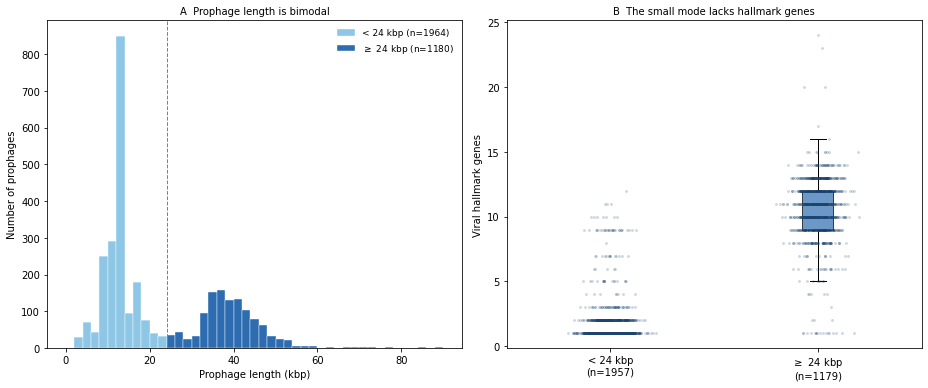

In [15]:
# Results 5.2.1 -- is prophage length bimodal? (supervisor comment 198)
# The mean (22.8 kbp) sits well above the median (14.4 kbp), so TS asked whether the
# distribution is really two populations: small satellite/cryptic/defective elements
# vs complete phage genomes. Length alone from data/confounders/prophage_length_table.csv;
# hallmark-gene counts merged in from data/all_proviruses_QC.tsv to show WHAT the two modes are.
import re
from scipy.stats import mannwhitneyu

TROUGH = 24000        # kbp cut between the two modes, read off the histogram trough

plen = pd.read_csv('data/confounders/prophage_length_table.csv')
# same filtering as the main text: drop ICE_community_99 and the seven singleton over-calls
gen = plen[(plen.pro_comm != 'PRO_com_99') & (plen.length <= 89400)].copy()
print(f'genuine prophages: n={len(gen)}, mean={gen.length.mean()/1000:.1f} kbp, '
      f'median={gen.length.median()/1000:.1f} kbp, max={gen.length.max()/1000:.1f} kbp')

# --- the distribution ---------------------------------------------------------
print('\nlength distribution (2 kbp bins):')
counts, edges = np.histogram(gen.length / 1000, bins=np.arange(0, 92, 2))
for c, e in zip(counts, edges):
    if c:
        print(f'  {e:4.0f}-{e+2:<4.0f} kbp  {c:4d}  ' + '#' * (c // 15))

# --- what are the two modes made of? -----------------------------------------
# key each prophage on contig + provirus coordinates so the QC table can be joined
pat = re.compile(r'^(\S+)_([A-Za-z0-9.]+)_provirus-(\d+)-(\d+)\.fna$')
gen['key'] = gen.prophage_id.map(lambda s: (lambda m: f'{m.group(2)}|{m.group(3)}|{m.group(4)}'
                                            if m else None)(pat.match(s)))

qc = pd.read_csv('data/all_proviruses_QC.tsv', sep='\t')
_contig = qc.seq_name.str.split('|', expand=True)
_coord = _contig[1].str.extract(r'provirus_(\d+)_(\d+)')
qc['key'] = _contig[0] + '|' + _coord[0] + '|' + _coord[1]
qc = qc.dropna(subset=['key']).drop_duplicates('key')

mg = (gen.dropna(subset=['key'])
         .merge(qc[['key', 'n_hallmarks', 'n_genes', 'virus_score']], on='key', how='left')
         .dropna(subset=['n_hallmarks']))
print(f'\nhallmark counts recovered for {len(mg)} of {len(gen)} prophages '
      f'({100*len(mg)/len(gen):.0f}%; the remainder have ID formats the join does not parse)')

mg['mode'] = np.where(mg.length < TROUGH, 'small', 'large')
summary = mg.groupby('mode').agg(n=('length', 'size'),
                                 median_kbp=('length', lambda s: s.median() / 1000),
                                 median_hallmarks=('n_hallmarks', 'median'),
                                 mean_hallmarks=('n_hallmarks', 'mean'),
                                 median_genes=('n_genes', 'median')).round(1)
print(summary.loc[['small', 'large']])
u, p = mannwhitneyu(mg.loc[mg['mode'] == 'small', 'n_hallmarks'],
                    mg.loc[mg['mode'] == 'large', 'n_hallmarks'])
print(f'hallmark genes, small vs large mode: Mann-Whitney p = {p:.3g}')

# --- figure ------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

bins = np.arange(0, 92, 2)
small = gen[gen.length < TROUGH].length / 1000
large = gen[gen.length >= TROUGH].length / 1000
ax1.hist([small, large], bins=bins, stacked=True, color=['#8ec6e6', '#2d6cb0'],
         edgecolor='white', linewidth=0.4,
         label=[f'< {TROUGH/1000:.0f} kbp (n={len(small)})',
                f'$\\geq$ {TROUGH/1000:.0f} kbp (n={len(large)})'])
ax1.axvline(TROUGH / 1000, color='grey', ls='--', lw=1)
ax1.set_xlabel('Prophage length (kbp)')
ax1.set_ylabel('Number of prophages')
ax1.set_title('A  Prophage length is bimodal', fontsize=10)
ax1.legend(frameon=False, fontsize=9)

groups = [mg.loc[mg['mode'] == m, 'n_hallmarks'].values for m in ['small', 'large']]
labels = [f'< {TROUGH/1000:.0f} kbp\n(n={len(groups[0])})',
          f'$\\geq$ {TROUGH/1000:.0f} kbp\n(n={len(groups[1])})']
bp = ax2.boxplot(groups, labels=labels, showfliers=False, patch_artist=True)
for patch, col in zip(bp['boxes'], ['#8ec6e6', '#2d6cb0']):
    patch.set_facecolor(col); patch.set_alpha(0.7)
for i, d in enumerate(groups, 1):
    ax2.scatter(np.random.normal(i, 0.06, len(d)), d, s=4, color='#1b4570', alpha=0.15, zorder=3)
ax2.set_ylabel('Viral hallmark genes')
ax2.set_title('B  The small mode lacks hallmark genes', fontsize=10)

fig.tight_layout()
fig.savefig('figures/prophage_length_bimodality.png', dpi=200, bbox_inches='tight')
plt.show()
